### Import packages, define paths and load data

In [62]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
DATA_DIR = PROJECT_ROOT / "data/associational_gender_bias"
FIGURES_DIR = PROJECT_ROOT / "results/figures"

In [64]:
gender_bias_df_literary_fiction = pd.read_csv(DATA_DIR / "literary_fiction_gender_bias_averaged_seeds.csv")
gender_bias_df_romance = pd.read_csv(DATA_DIR / "romance_gender_bias_averaged_seeds.csv")
gender_bias_df_sci_fi = pd.read_csv(DATA_DIR / "sci_fi_gender_bias_averaged_seeds.csv")

# add a column for genre
gender_bias_df_literary_fiction["genre"] = "Literary Fiction"
gender_bias_df_romance["genre"] = "Romance"
gender_bias_df_sci_fi["genre"] = "Sci-Fi"

# merge the three dataframes into one
gender_bias_df = pd.concat([gender_bias_df_literary_fiction, gender_bias_df_romance, gender_bias_df_sci_fi], ignore_index=True)

In [65]:
gender_bias_df_literary_fiction_no_names = pd.read_csv(DATA_DIR / "literary_fiction_no_names_gender_bias_averaged_seeds.csv")
gender_bias_df_romance_no_names = pd.read_csv(DATA_DIR / "romance_no_names_gender_bias_averaged_seeds.csv")
gender_bias_df_sci_fi_no_names = pd.read_csv(DATA_DIR / "sci_fi_no_names_gender_bias_averaged_seeds.csv")

# add a column for genre
gender_bias_df_literary_fiction_no_names["genre"] = "Literary Fiction"
gender_bias_df_romance_no_names["genre"] = "Romance"
gender_bias_df_sci_fi_no_names["genre"] = "Sci-Fi"

# merge the three dataframes into one
gender_bias_df_no_names = pd.concat([gender_bias_df_literary_fiction_no_names, gender_bias_df_romance_no_names, gender_bias_df_sci_fi_no_names], ignore_index=True)

In [66]:
# rename dimensions
gender_bias_df["dimension"] = gender_bias_df["dimension"].replace({
    "high_warmth": "High Warmth",
    "high_competence": "High Competence",
    "low_competence": "Low Competence",
    "low_warmth": "Low Warmth"})

### Violin plot

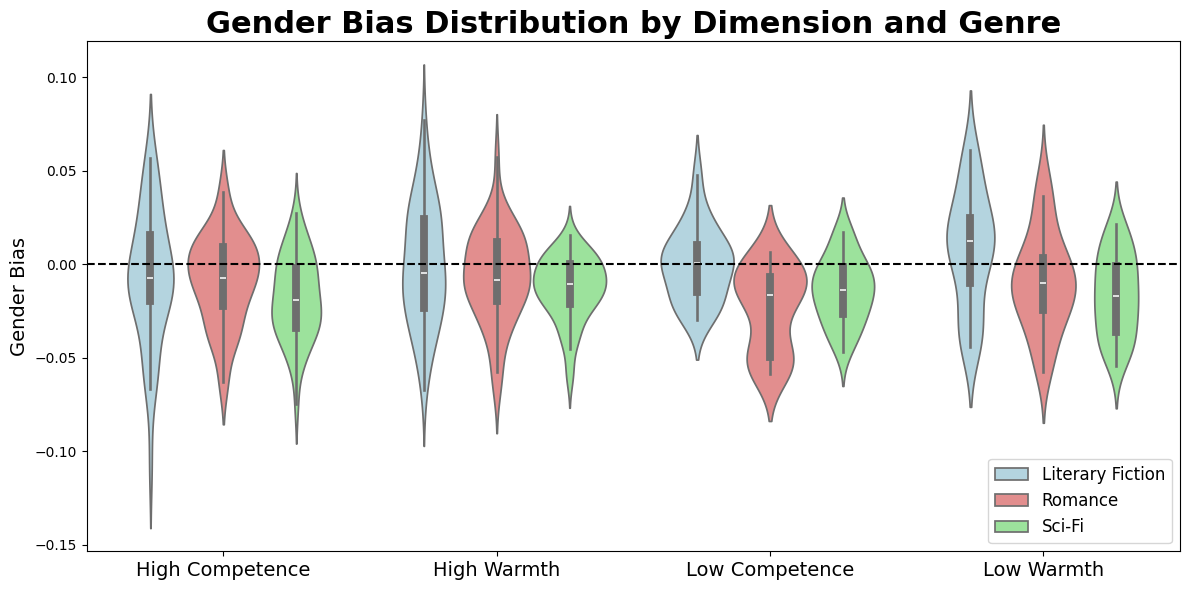

In [67]:
genre_colors = {
    "Literary Fiction": "lightblue", 
    "Romance": "lightcoral",          
    "Sci-Fi": "lightgreen"             
}

plt.figure(figsize=(12, 6))
sns.violinplot(x="dimension", y="gender_bias", hue="genre", data=gender_bias_df, 
               palette=genre_colors, split=False)
plt.title("Gender Bias Distribution by Dimension and Genre", fontsize=22, fontweight="bold")
plt.xlabel(None)
plt.xticks(fontsize=14, rotation=0)
plt.ylabel("Gender Bias", fontsize=14)
plt.axhline(0, color="black", linestyle="--")
plt.legend(fontsize=12, loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "Associational_bias/gender_bias_violin_plot.png", dpi=300)
plt.show()

### Point Plot

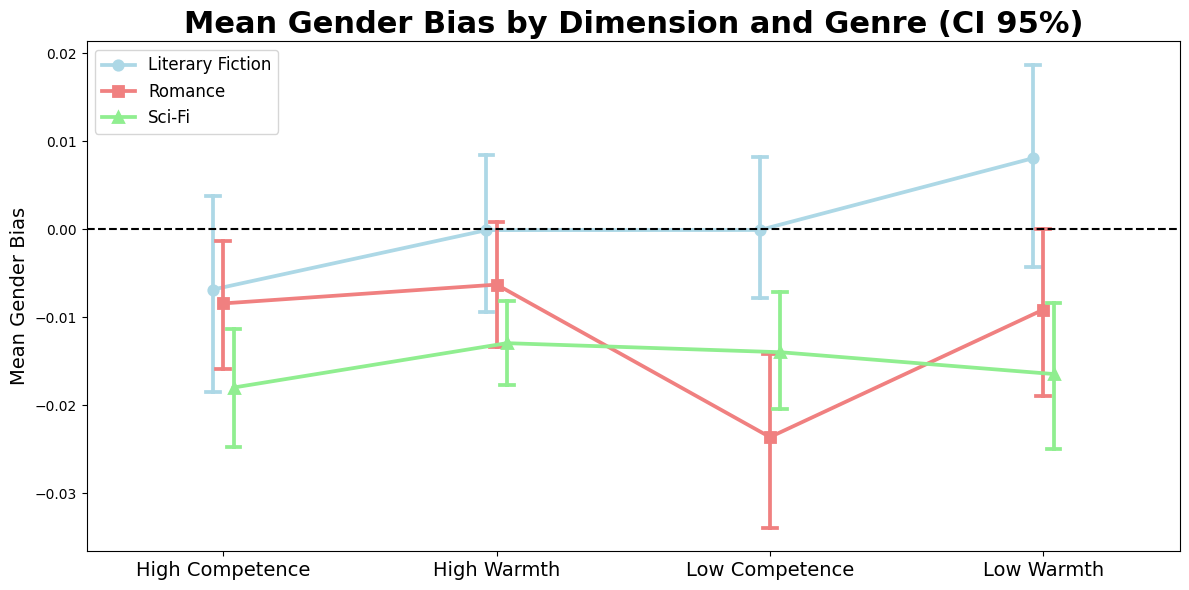

In [68]:
plt.figure(figsize=(12, 6))
sns.pointplot(
    x="dimension", 
    y="gender_bias", 
    hue="genre",
    data=gender_bias_df,
    palette=genre_colors,
    markers=["o", "s", "^"],
    linestyles="-",
    dodge=True,  # slightly separates points to avoid overlap
    capsize=0.05,  # adds caps to error bars
    errorbar="ci"  # 95% confidence interval
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Mean Gender Bias by Dimension and Genre (CI 95%)", fontsize=22, fontweight="bold")
plt.xlabel(None)
plt.ylabel("Mean Gender Bias", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.xticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "Associational_bias/gender_bias_point_plot.png", dpi=300)
plt.show()

### Bar plot

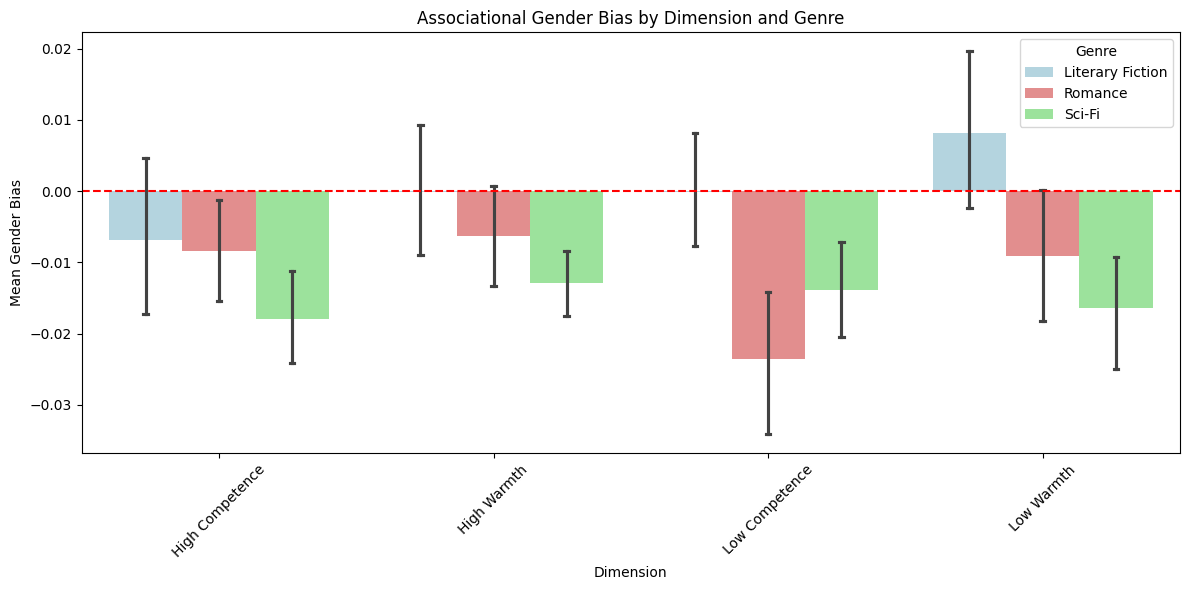

In [69]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="dimension",
    y="gender_bias",
    hue="genre",
    data=gender_bias_df,
    palette=genre_colors,
    capsize=0.05,  # adds caps to error bars
    errorbar="ci"  # 95% confidence interval
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Associational Gender Bias by Dimension and Genre")
plt.xlabel("Dimension")
plt.ylabel("Mean Gender Bias")
plt.legend(title="Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "Associational_bias/gender_bias_bar_plot.png", dpi=300)
plt.show()

### Horizontal bar plot

In [70]:
def plot_gender_bias_words(df, genre_name, dimensions = ["low_warmth", "low_competence", "high_warmth", "high_competence"]):
    """
    Plots a 2x2 grid of horizontal bar plots for each dimension in the dataframe.
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 18))
    axes = axes.flatten()  # flatten 2x2 array for easy indexing
    
    for i, dim in enumerate(dimensions):
        dim_df = df[df["dimension"] == dim]
        word_bias = dim_df.groupby("word")["gender_bias"].mean().sort_values()
        
        colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
        word_bias.plot(kind="barh", color=colors, ax=axes[i])
        
        # Remove y-axis tick labels
        axes[i].set_yticks([])
        
        # Add word labels at the end of each bar
        for j, (word, value) in enumerate(word_bias.items()):
            if value > 0:
                axes[i].text(value + 0.001, j, word, va="center", ha="left", fontsize=12)
            else:
                axes[i].text(value - 0.001, j, word, va="center", ha="right", fontsize=12)
        
        axes[i].axvline(0, color="black", linestyle="--")
        axes[i].set_title(f"{dim.replace('_', ' ').title()} Dimension", fontsize=18, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].set_xlim(-0.1, 0.1)
    
    fig.suptitle(f"Gender Bias for Individual Words in {genre_name}", fontsize=28, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])  # leave space for suptitle
    plt.savefig(FIGURES_DIR / f"Associational_bias/{genre_name}_gender_bias_words.png", dpi=300)
    plt.show()

##### Literary Fiction

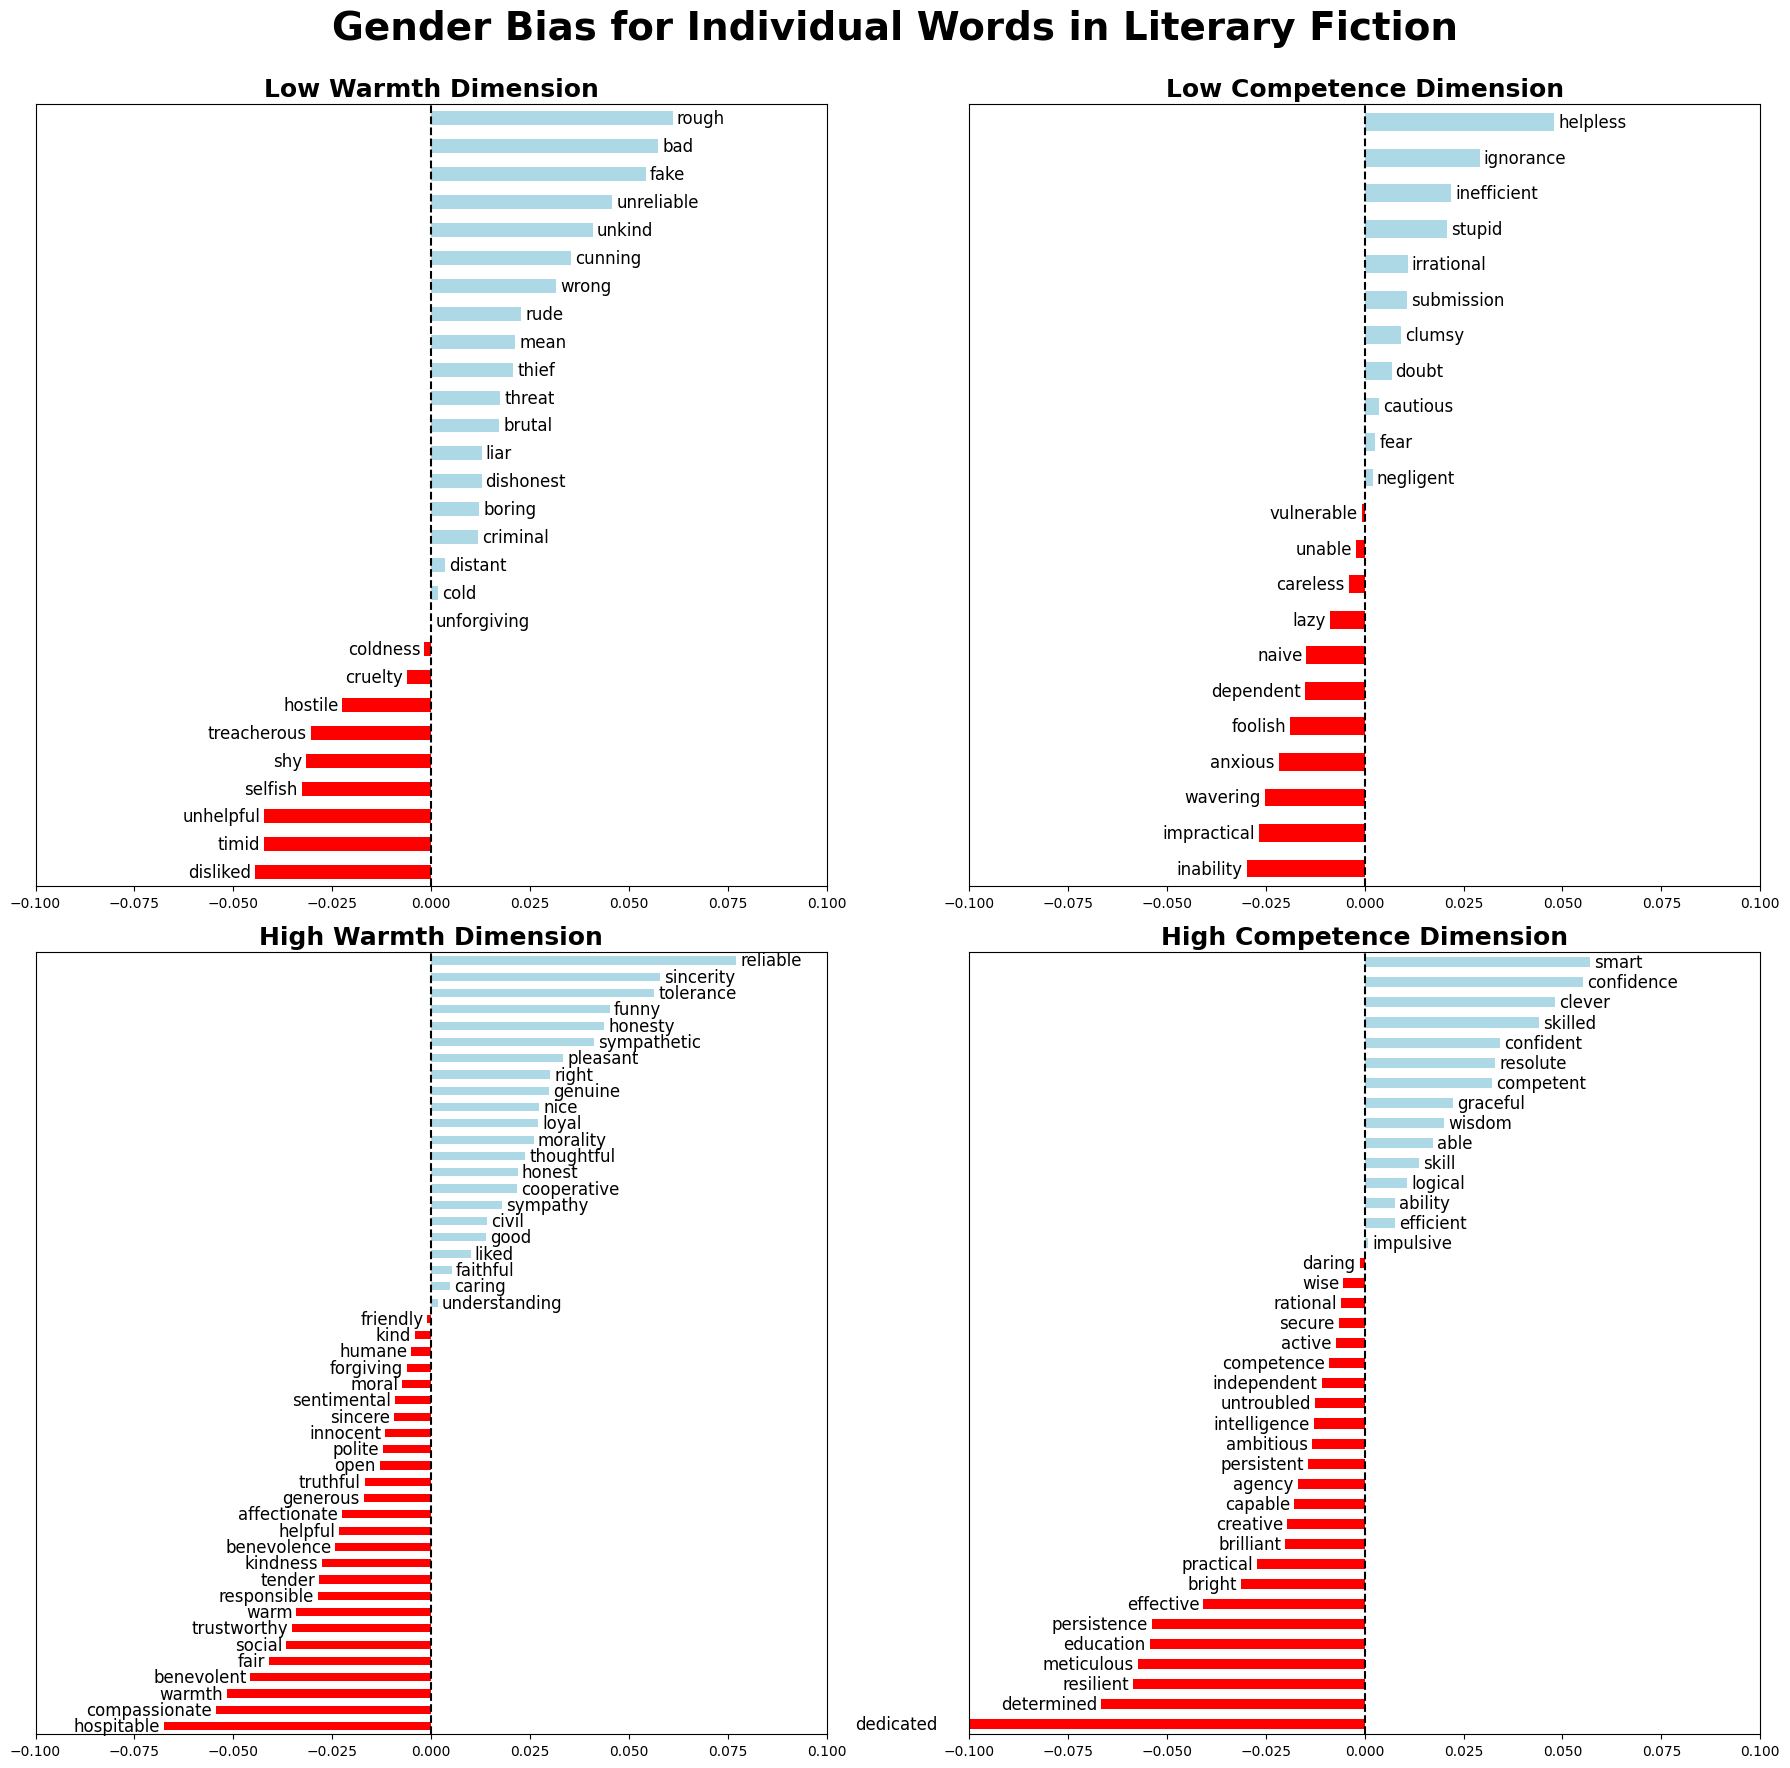

In [71]:
plot_gender_bias_words(gender_bias_df_literary_fiction, "Literary Fiction")

##### Romance

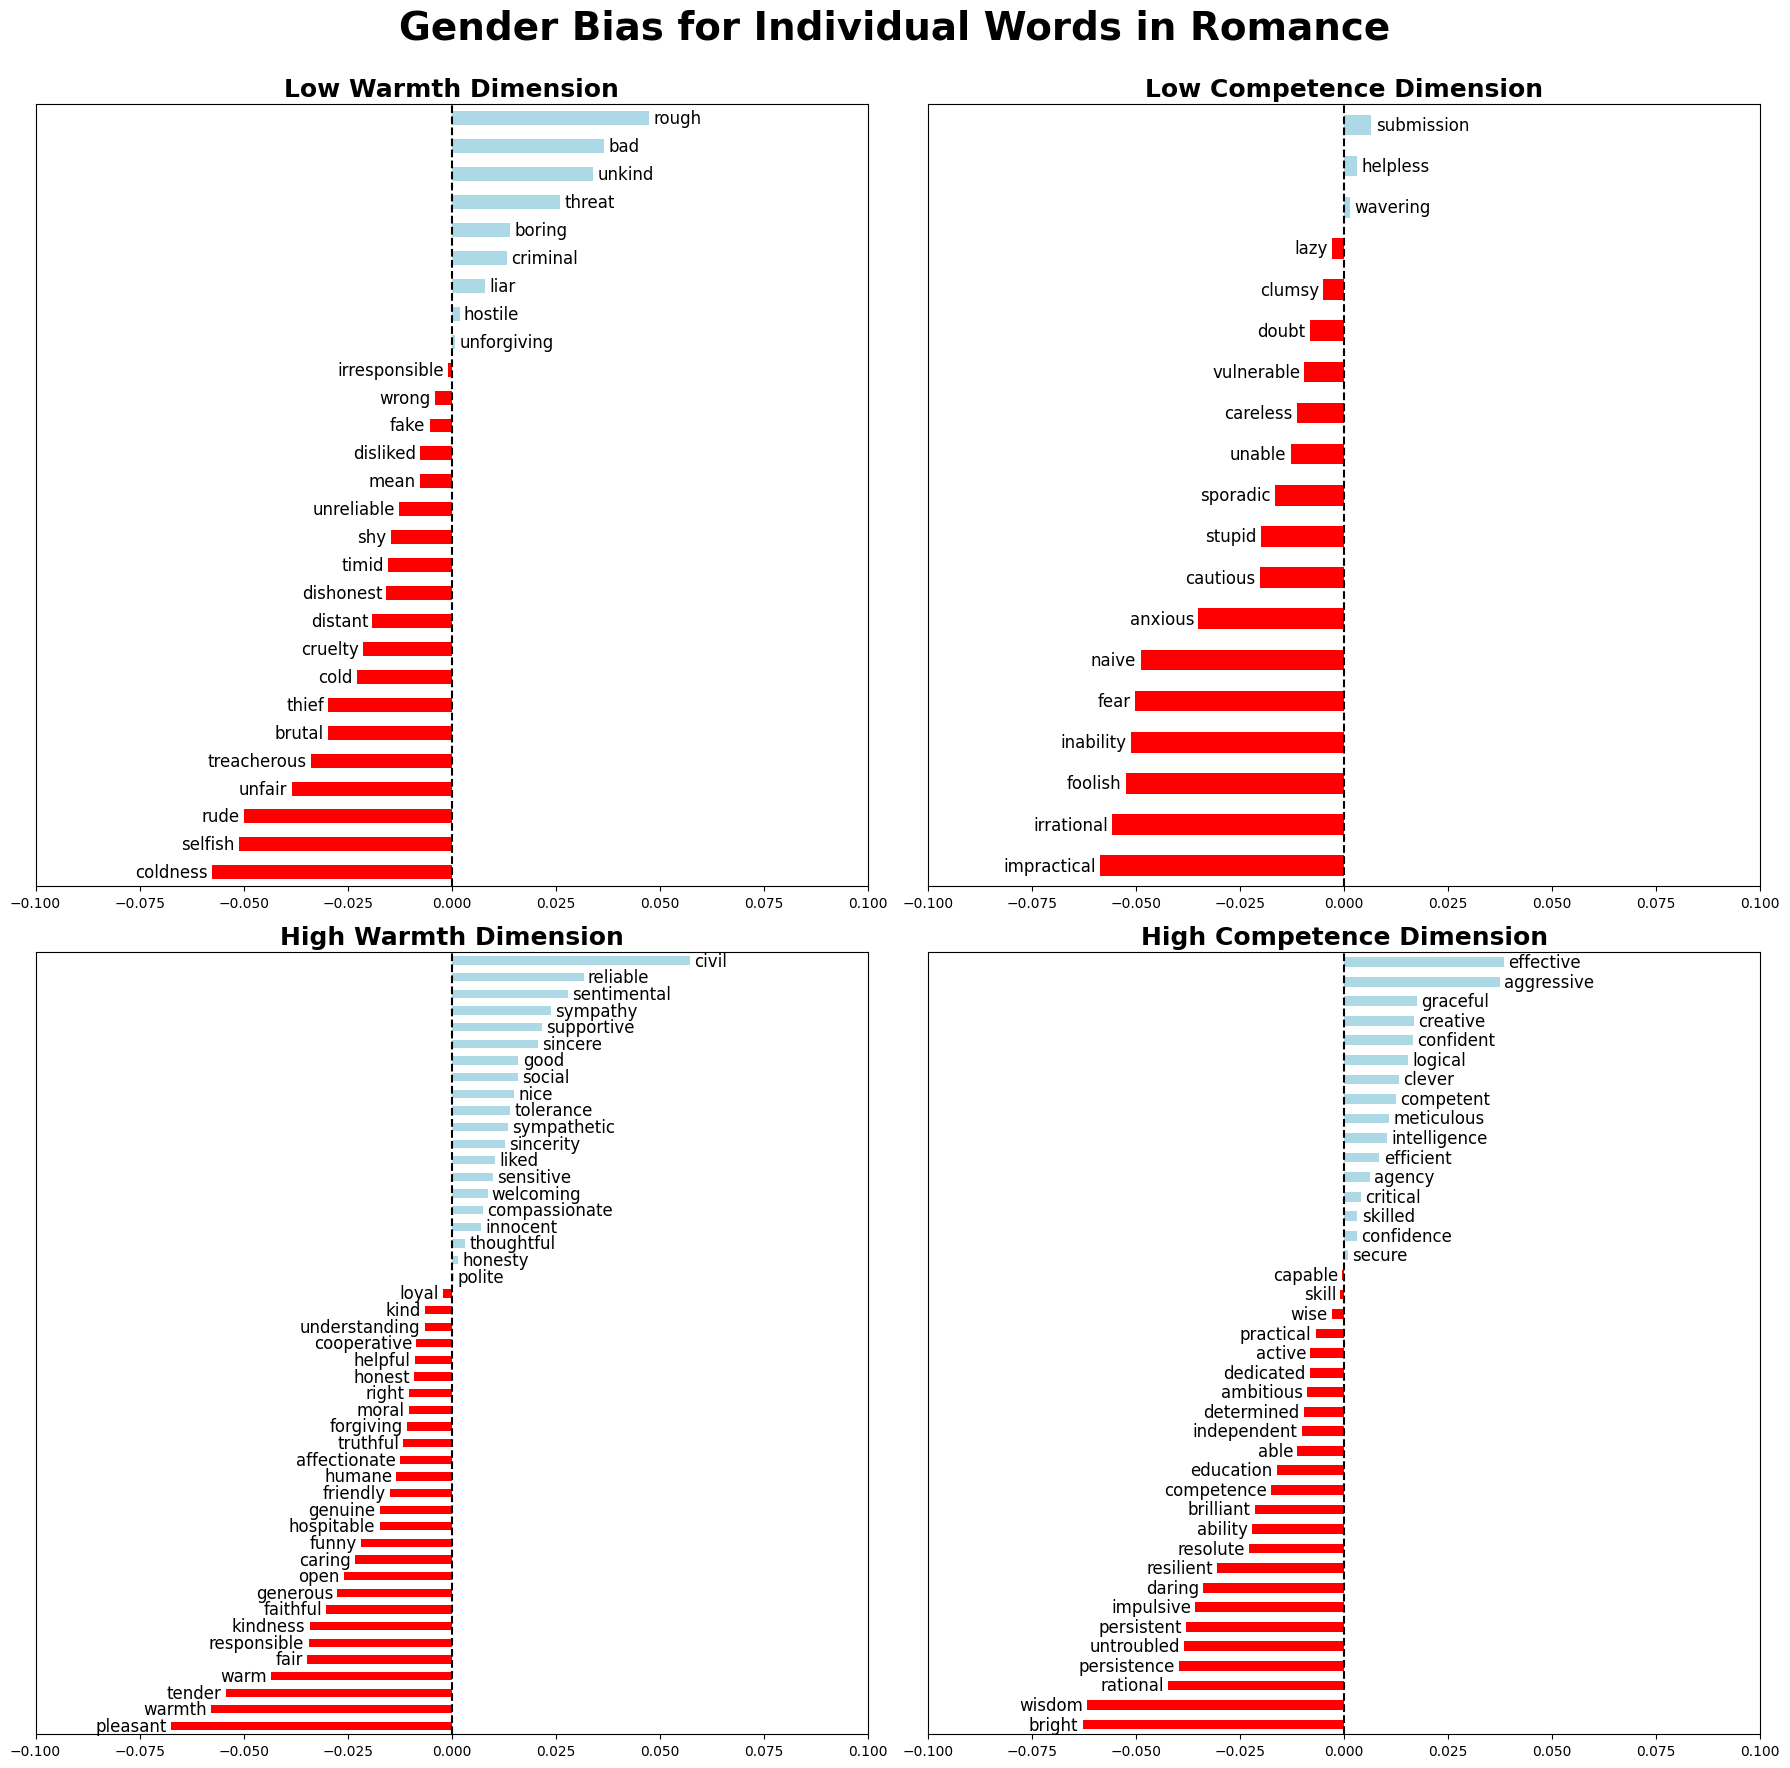

In [72]:
plot_gender_bias_words(gender_bias_df_romance, "Romance")

##### Sci Fi

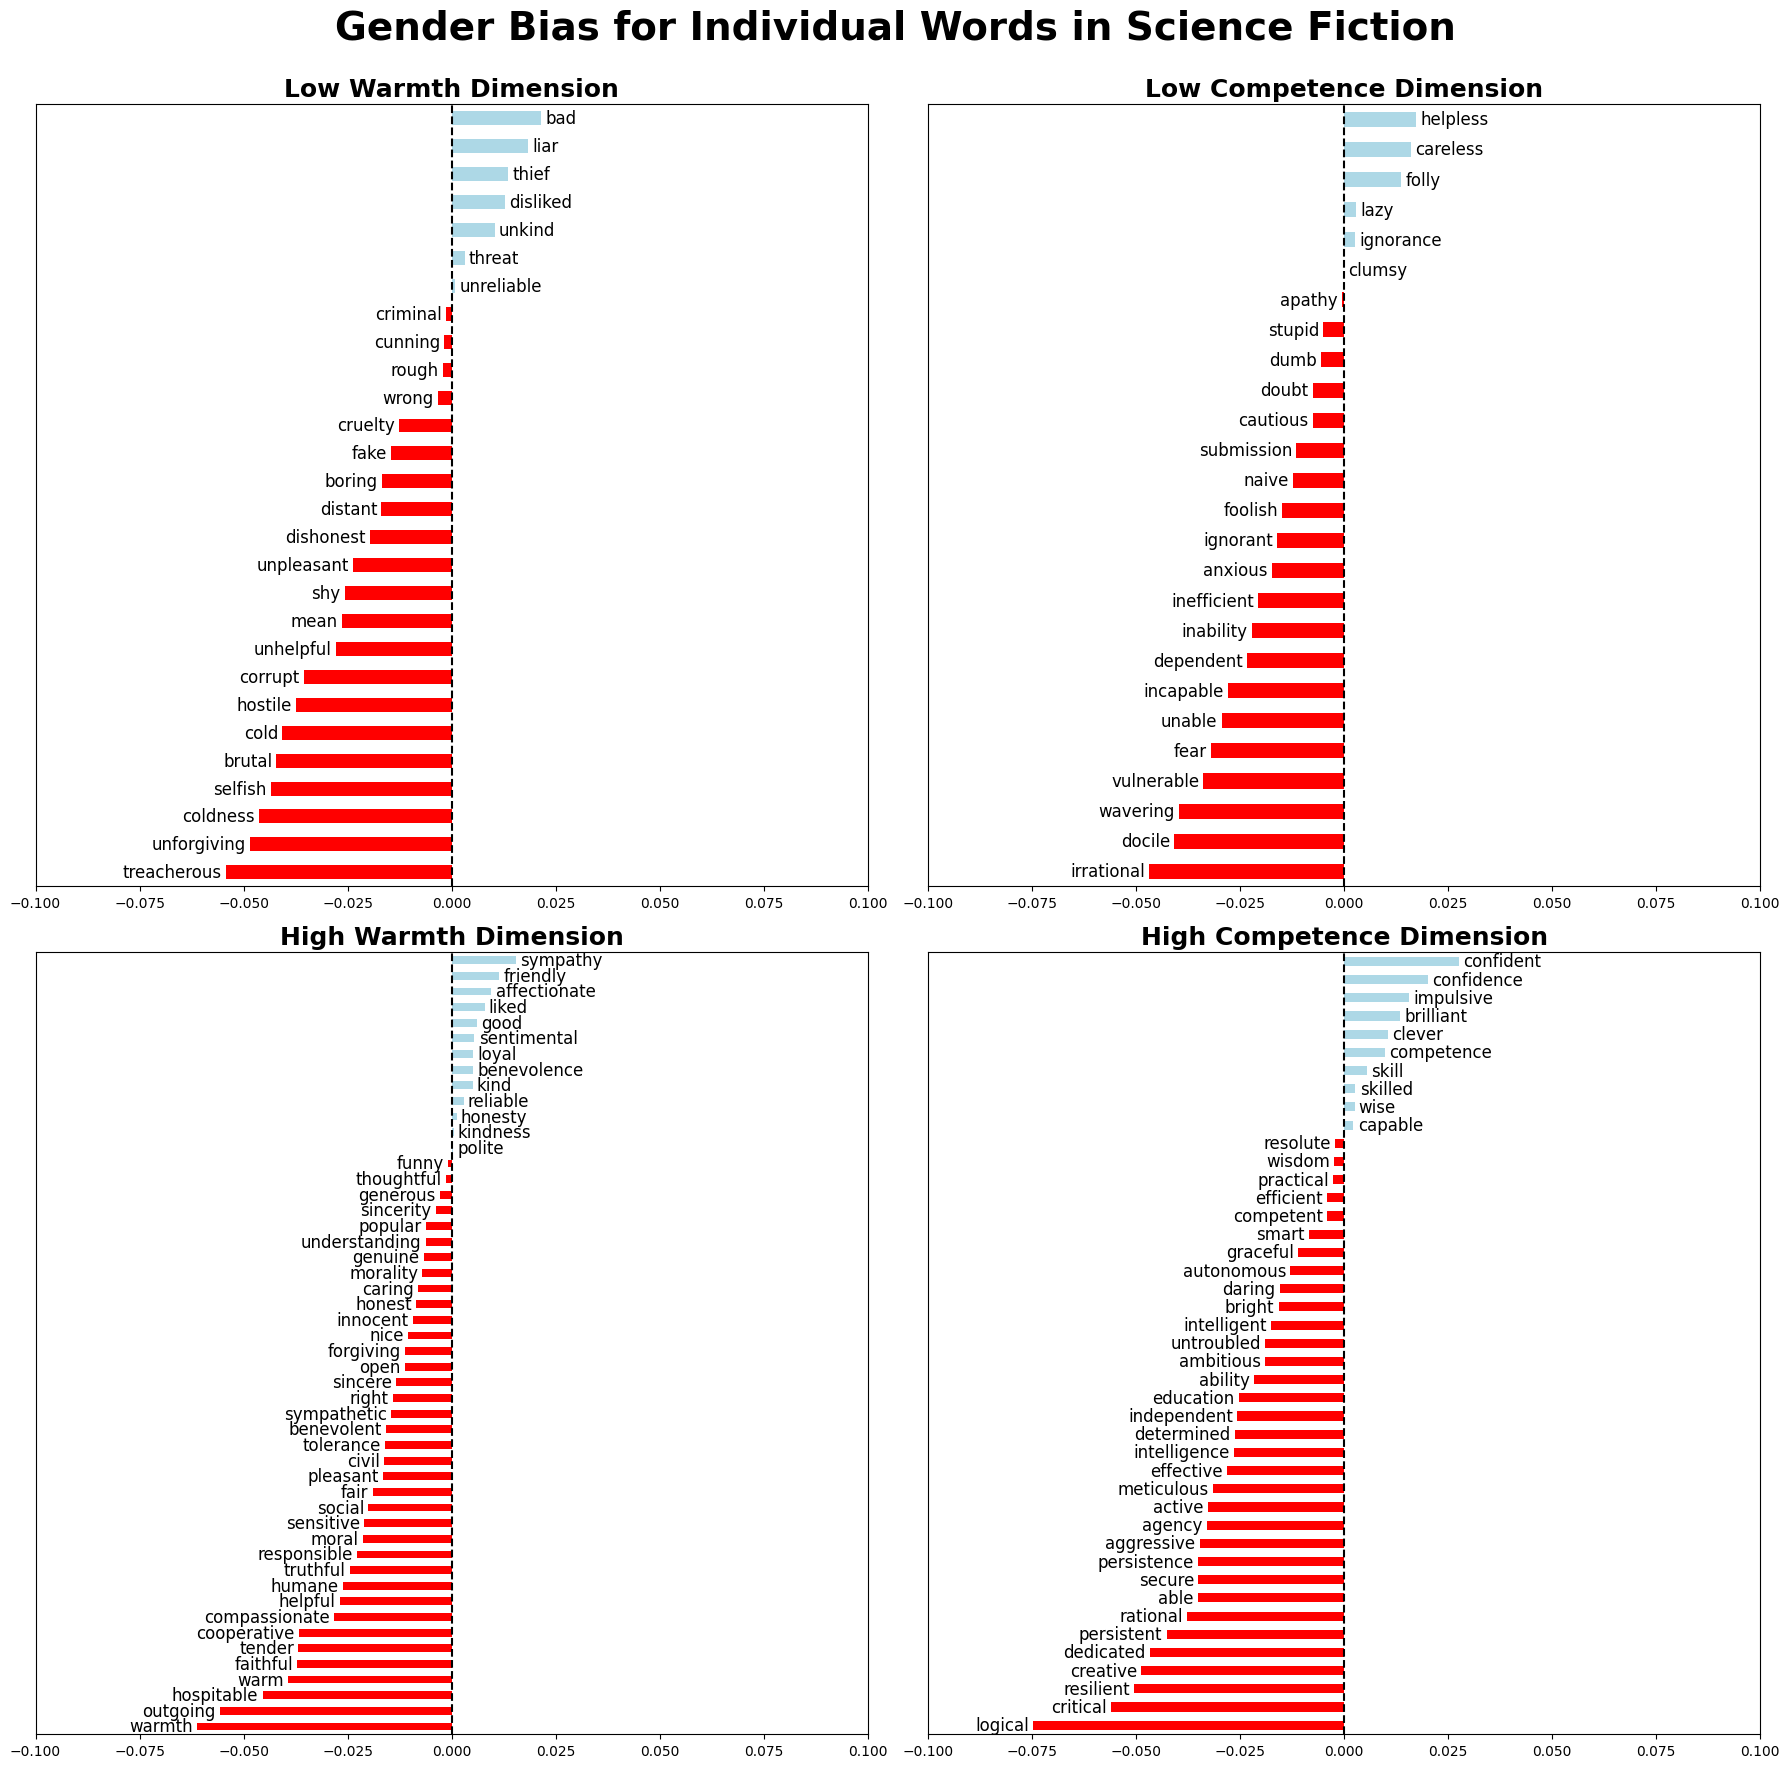

In [73]:
plot_gender_bias_words(gender_bias_df_sci_fi, "Science Fiction")

##### All genres

In [74]:
# for each word, average over all genres
gender_bias_df_avg = gender_bias_df.groupby(["dimension", "word"])["gender_bias"].mean().reset_index()

In [75]:
gender_bias_df_avg

,dimension,word,gender_bias
0,High Competence,ability,-0.012056
1,High Competence,able,-0.009711
2,High Competence,active,-0.016071
3,High Competence,agency,-0.014568
4,High Competence,aggressive,0.001305
...,...,...,...
152,Low Warmth,unhelpful,-0.035034
153,Low Warmth,unkind,0.028382
154,Low Warmth,unpleasant,-0.023641
155,Low Warmth,unreliable,0.011344


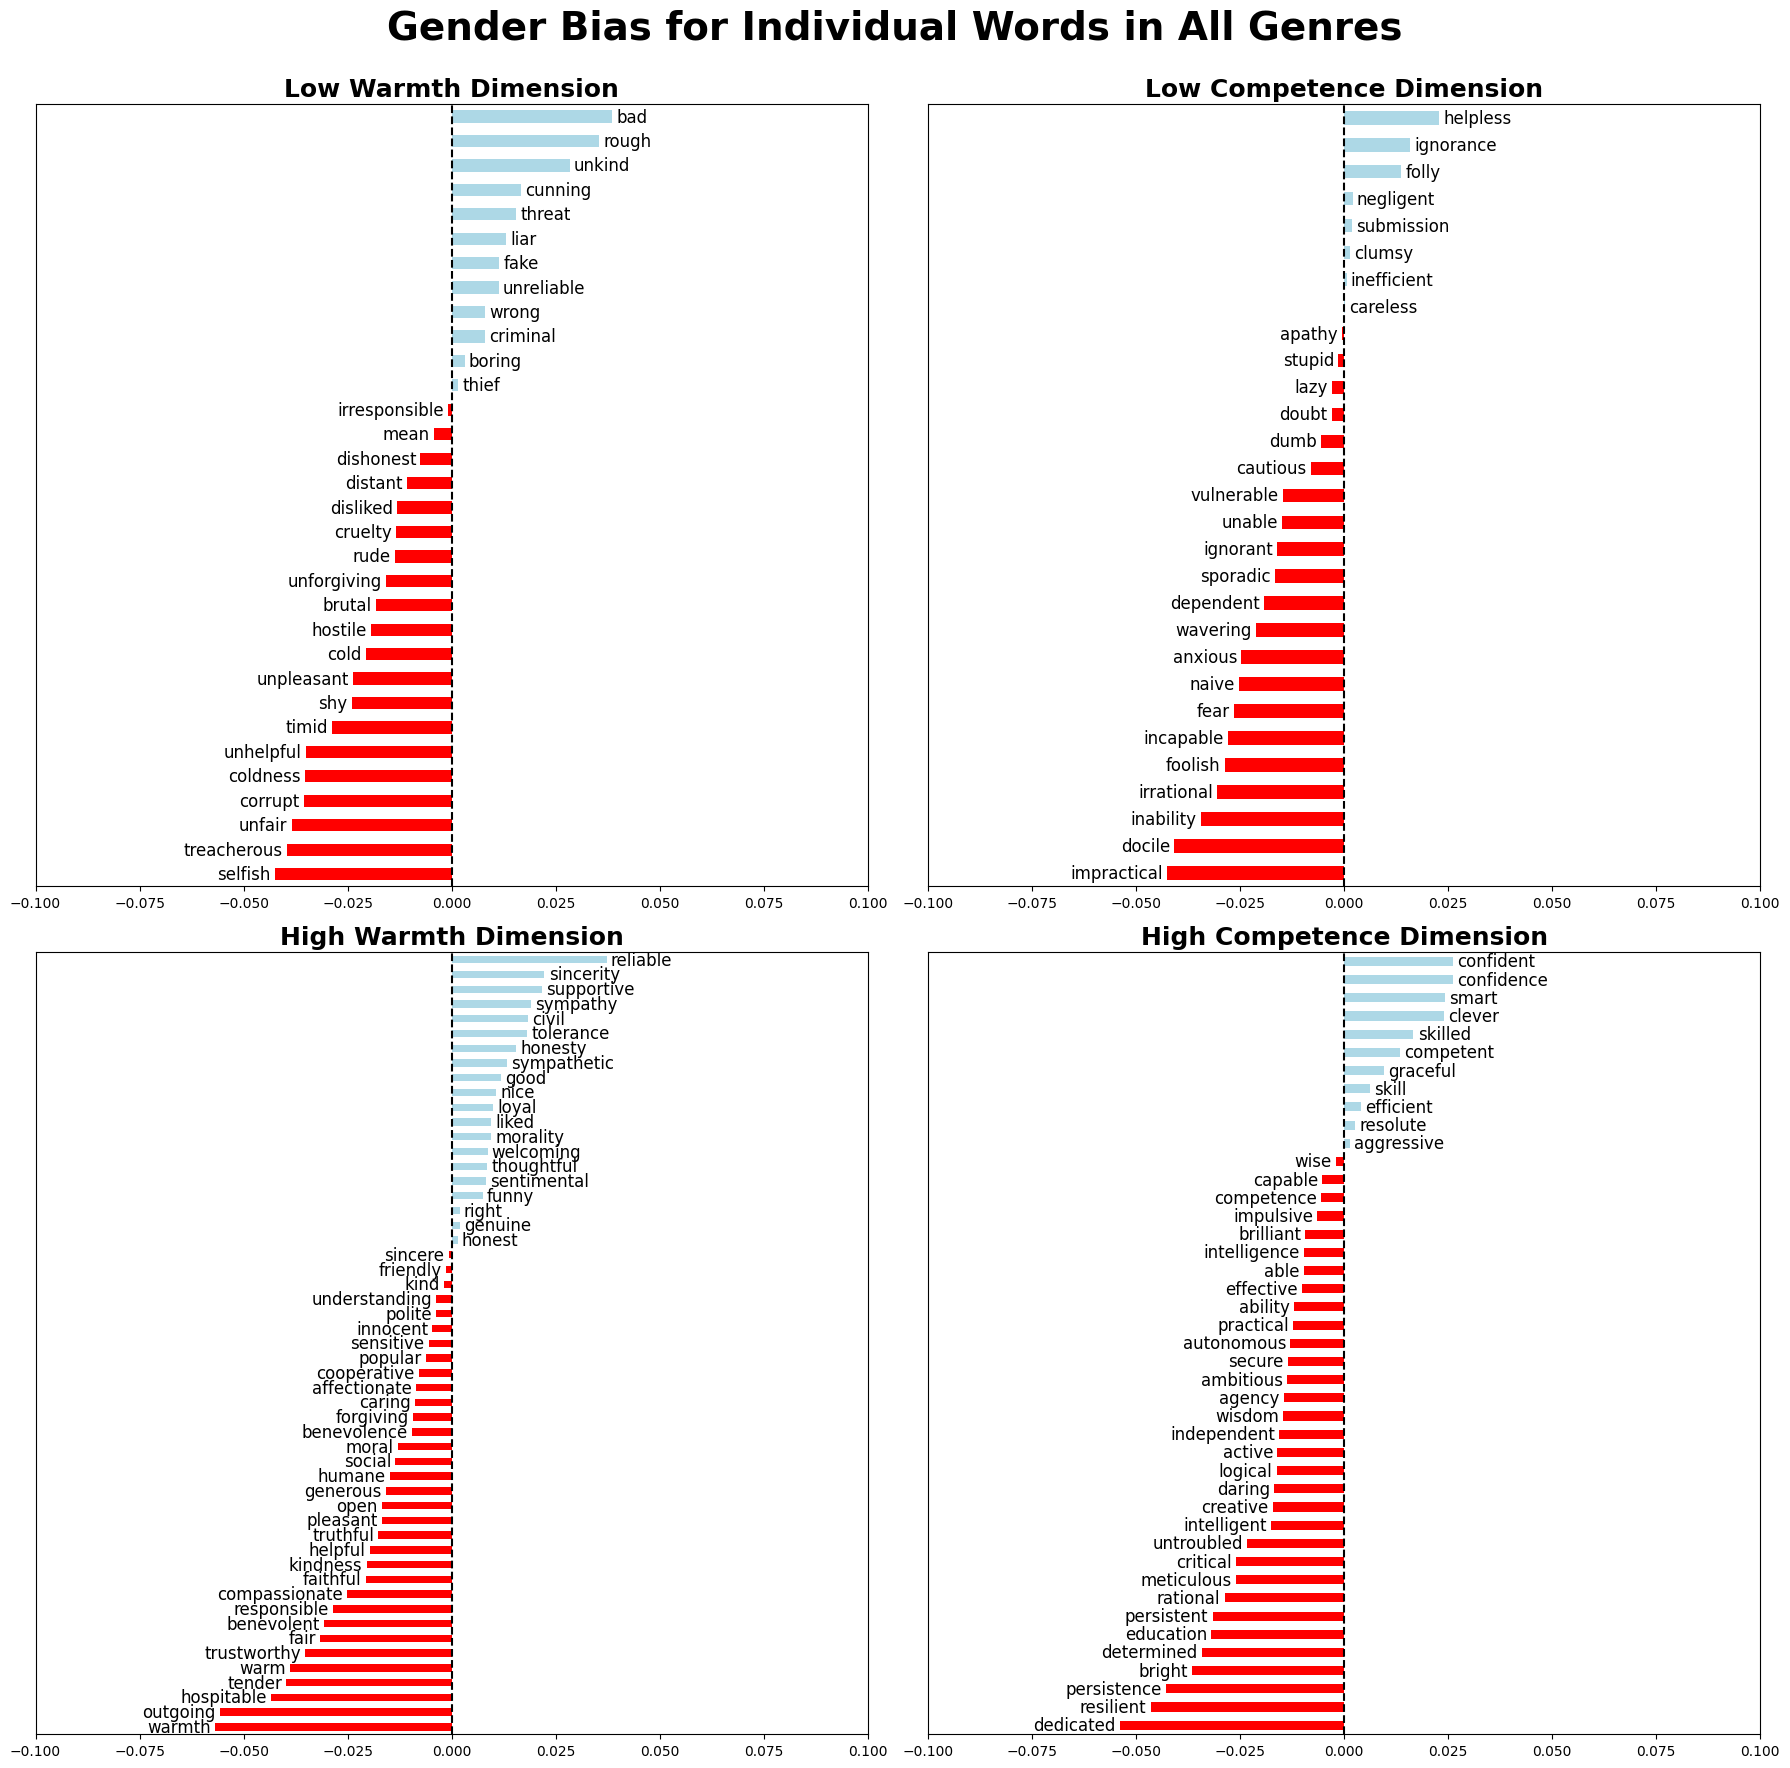

In [76]:
plot_gender_bias_words(gender_bias_df_avg, "All Genres", dimensions=["Low Warmth", "Low Competence", "High Warmth", "High Competence"])